# MS Feature Engineering

Feature engineering complete.
Input rows:    6958
Features added: ['ANALYTICAL_TYPE', 'QC_TYPE', 'STD_CODE', 'JOB_CODE', 'PRECISION_STATUS', 'INTERNAL_MIN_INCLUSIVE', 'INTERNAL_MAX_INCLUSIVE', 'INTERNAL_MIN_WARNING_INCLUSIVE', 'INTERNAL_MAX_WARNING_INCLUSIVE', 'LIM_REP_VALUE', 'STAT_DL_VALUE', 'LIM_REP_DUP_VALUE', 'STAT_DL_DUP_VALUE', 'PARENT_NUMERIC_FINAL_VALUE', 'UNIT_CODE', 'SPECIFICATION_CODE', 'INSTRUMENT_ID', 'IS_IGNORED', 'TARGET_DEVIATION', 'TARGET_DEVIATION_PCT', 'NORM_DEV', 'ABS_NORM_DEV', 'DISTANCE_TO_UPPER_FAILURE', 'DISTANCE_TO_LOWER_FAILURE', 'LIMIT_SPAN', 'POSITION_IN_RANGE', 'ROLLING_MEAN_NORM_DEV', 'ROLLING_STD_NORM_DEV', 'ROLLING_BREACH_COUNT', 'GROUP_MEDIAN', 'ABS_DEV_FROM_MEDIAN', 'GROUP_MAD', 'ROBUST_Z_SCORE']
Null counts in key features:
  TARGET_DEVIATION               0 nulls
  TARGET_DEVIATION_PCT           0 nulls
  NORM_DEV                       0 nulls
  ROLLING_MEAN_NORM_DEV          258 nulls
  ROBUST_Z_SCORE                 86 nulls


/var/folders/3q/0mjntz6s55qg6qc4g9vvjfyc0000gn/T/ipykernel_49538/485934420.py:408: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_status, labels=status_order, patch_artist=True,


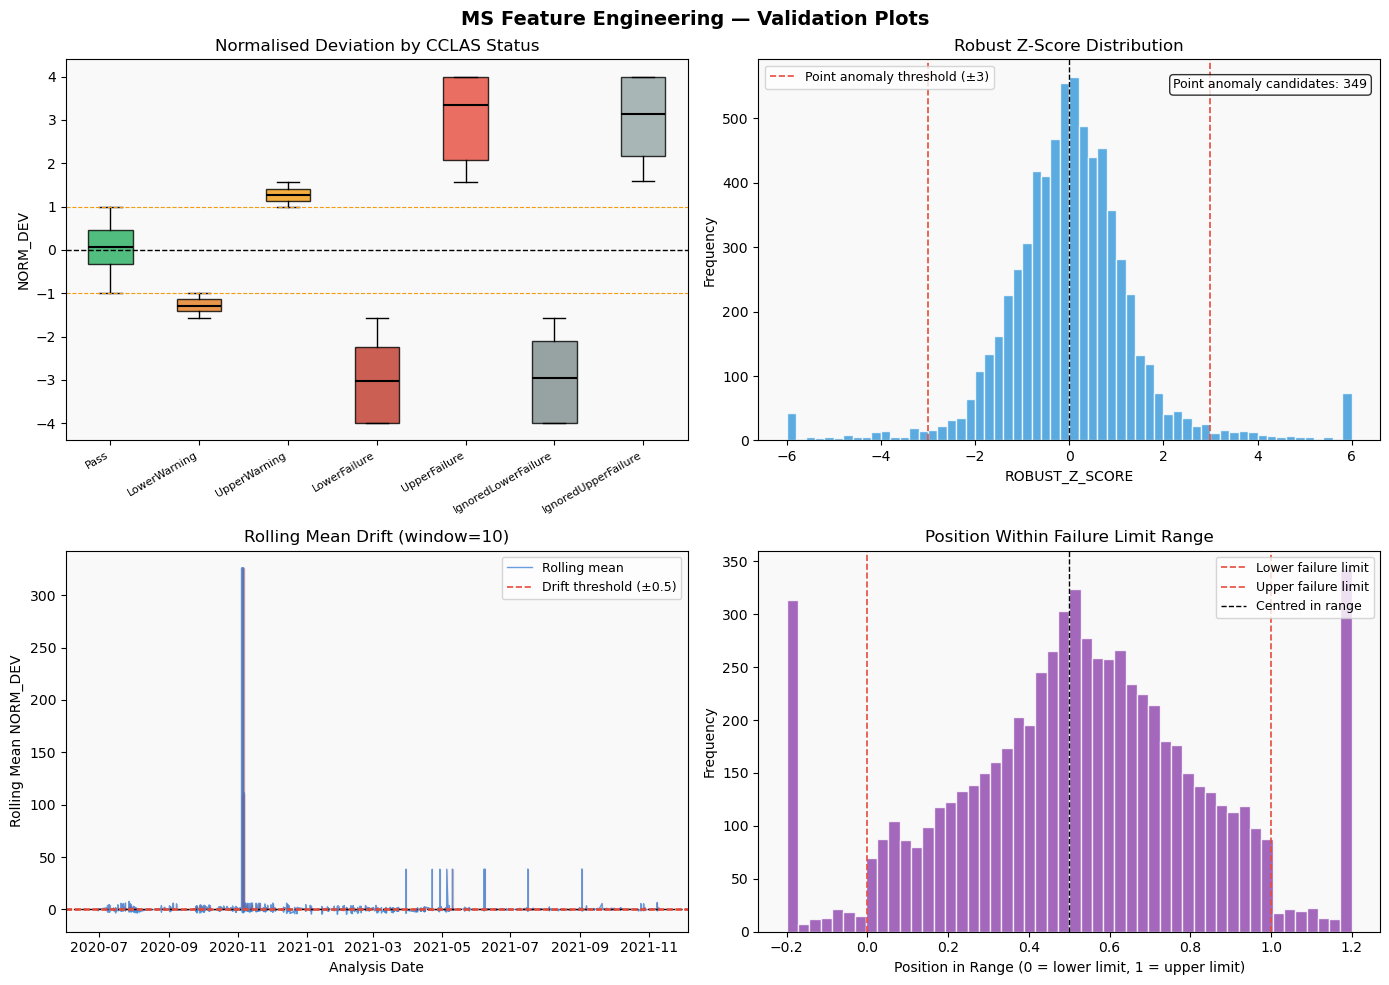


Feature output preview:
  ANALYTE_CODE  SCHEME_CODE  NUMERIC_FINAL_VALUE  INTERNAL_TARGET_VALUE STANDARD_STATUS  TARGET_DEVIATION  TARGET_DEVIATION_PCT  NORM_DEV  ABS_NORM_DEV  POSITION_IN_RANGE  ROLLING_MEAN_NORM_DEV  ROLLING_STD_NORM_DEV  ROLLING_BREACH_COUNT  GROUP_MEDIAN  GROUP_MAD  ROBUST_Z_SCORE
0           AG  GE_ICP40Q12             1.234450                  0.779            Pass          0.455450             58.465951  0.540751      0.540751           0.671495                    NaN                   NaN                   NaN      0.451669   0.206485        0.290991
1           AG  GE_ICP40Q12             1.543689                  0.779            Pass          0.764689             98.162942  0.907907      0.907907           0.787935                    NaN                   NaN                   NaN      0.451669   0.206485        1.490337
2           AG  GE_ICP40Q12             1.650000                  0.779    UpperWarning          0.871000            111.810013  1.034129 

In [4]:

# This module derives all features required for Matrix Spike anomaly detection.
# Since PARENT_NUMERIC_FINAL_VALUE is entirely null in the current export,
# recovery percentage cannot be computed. All features are therefore derived
# from deviation between NUMERIC_FINAL_VALUE and INTERNAL_TARGET_VALUE.
#
# Features derived:
#   1. TARGET_DEVIATION          — signed distance from certified target
#   2. TARGET_DEVIATION_PCT      — deviation as a percentage of target
#   3. NORM_DEV                  — normalised deviation score (0 to +-1 scale)
#   4. ABS_NORM_DEV              — absolute normalised deviation
#   5. DISTANCE_TO_UPPER_FAILURE — headroom to upper failure limit
#   6. DISTANCE_TO_LOWER_FAILURE — headroom to lower failure limit
#   7. LIMIT_SPAN                — total span between failure limits
#   8. POSITION_IN_RANGE         — relative position within the limit span (0-1)
#   9. ROLLING_MEAN_NORM_DEV     — rolling mean of normalised score (drift)
#  10. ROLLING_STD_NORM_DEV      — rolling std of normalised score (instability)
#  11. ROLLING_BREACH_COUNT      — count of consecutive boundary breaches
#  12. GROUP_MEDIAN              — per-group median normalised deviation
#  13. GROUP_MAD                 — per-group median absolute deviation
#  14. ROBUST_Z_SCORE            — MAD-based z-score for point anomaly detection
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

# Grouping columns — all features computed within these groups
# Single lot (OREAS_502C) so STD_LOT_CODE adds no segmentation value here,
# but is included for forward compatibility when more lots are added
GROUP_COLS = ["STD_LOT_CODE", "SCHEME_CODE", "ANALYTE_CODE"]

# Rolling window for temporal features
ROLLING_WINDOW     = 10   # number of consecutive observations
ROLLING_MIN_PERIODS = 3   # minimum observations before rolling features are computed

# Drift detection threshold — rolling mean must exceed this to flag drift
DRIFT_THRESHOLD = 0.5

# Ignored status values — excluded from group baselines
IGNORED_STATUSES = {"IgnoredUpperFailure", "IgnoredLowerFailure"}

# Scaling factor for MAD-based robust z-score
# 0.6745 makes the score equivalent to a standard z-score under normality
MAD_SCALE = 0.6745


# ---------------------------------------------------------------------------
# Main function
# ---------------------------------------------------------------------------

def engineer_ms_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive all anomaly detection features for Matrix Spike records.

    Parameters
    ----------
    df : pd.DataFrame
        Filtered Matrix Spike DataFrame from check_classifier.
        Must contain NUMERIC_FINAL_VALUE, INTERNAL_TARGET_VALUE,
        INTERNAL_MIN/MAX_VALUE, INTERNAL_MIN/MAX_WARNING_VALUE,
        ANALYSED_DATE, ANALYTE_CODE, SCHEME_CODE, STD_LOT_CODE,
        and STANDARD_STATUS.

    Returns
    -------
    pd.DataFrame with all original columns plus derived feature columns.
    """
    df = df.copy()

    # Step 1 — validate required columns
    _validate_columns(df)

    # Step 2 — coerce numeric types
    df = _coerce_numerics(df)

    # Step 3 — exclude ignored results from group baseline computation
    #           (they are kept in the DataFrame but not used for medians/MAD)
    df["IS_IGNORED"] = df["STANDARD_STATUS"].isin(IGNORED_STATUSES)

    # Step 4 — sort chronologically within each group for rolling features
    df = df.sort_values(["STD_LOT_CODE", "SCHEME_CODE", "ANALYTE_CODE", "ANALYSED_DATE"])
    df = df.reset_index(drop=True)

    # Step 5 — derive features
    df = _deviation_features(df)
    df = _normalised_deviation(df)
    df = _limit_position_features(df)
    df = _rolling_features(df)
    df = _group_baseline_features(df)
    df = _robust_z_score(df)

    print(f"Feature engineering complete.")
    print(f"Input rows:    {len(df)}")
    print(f"Features added: {[c for c in df.columns if c not in _original_cols(df)]}")
    print(f"Null counts in key features:")
    key_features = [
        "TARGET_DEVIATION", "TARGET_DEVIATION_PCT", "NORM_DEV",
        "ROLLING_MEAN_NORM_DEV", "ROBUST_Z_SCORE"
    ]
    for col in key_features:
        if col in df.columns:
            print(f"  {col:<30} {df[col].isna().sum()} nulls")

    return df


# ---------------------------------------------------------------------------
# Step functions
# ---------------------------------------------------------------------------

def _deviation_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature 1: TARGET_DEVIATION
    Signed distance between the measured result and the certified target.
    Positive = above target (potential inflation / matrix enhancement).
    Negative = below target (potential suppression / matrix interference).

    Feature 2: TARGET_DEVIATION_PCT
    Deviation expressed as a percentage of the target value.
    Negative targets and near-zero targets produce undefined percentages —
    these are set to NaN rather than propagating unreliable values.
    298 rows have negative NUMERIC_FINAL_VALUE; these are retained because
    negative results are physically possible near the detection limit and
    the deviation is still meaningful relative to the target.
    """
    df["TARGET_DEVIATION"] = df["NUMERIC_FINAL_VALUE"] - df["INTERNAL_TARGET_VALUE"]

    df["TARGET_DEVIATION_PCT"] = np.where(
        df["INTERNAL_TARGET_VALUE"].abs() > 1e-9,
        (df["TARGET_DEVIATION"] / df["INTERNAL_TARGET_VALUE"]) * 100,
        np.nan
    )

    return df


def _normalised_deviation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature 3: NORM_DEV — Normalised deviation score (0 to +-1 scale)
    Places each result on a common scale relative to its warning boundary
    so analytes at very different concentration scales can be compared.

        norm_dev = deviation / (warning_bound - target)

    Where warning_bound is:
        INTERNAL_MAX_WARNING_VALUE if result >= target (upper deviation)
        INTERNAL_MIN_WARNING_VALUE if result <  target (lower deviation)

    Score interpretation:
         0    = exactly on target
        +1    = at the upper warning boundary
        -1    = at the lower warning boundary
        > +1  = beyond upper warning (into warning or failure zone)
        < -1  = beyond lower warning (into warning or failure zone)

    Feature 4: ABS_NORM_DEV — absolute value for unsigned magnitude.
    """
    upper_span = df["INTERNAL_MAX_WARNING_VALUE"] - df["INTERNAL_TARGET_VALUE"]
    lower_span = df["INTERNAL_TARGET_VALUE"] - df["INTERNAL_MIN_WARNING_VALUE"]

    df["NORM_DEV"] = np.where(
        df["NUMERIC_FINAL_VALUE"] >= df["INTERNAL_TARGET_VALUE"],
        np.where(upper_span.abs() > 1e-9,
                 df["TARGET_DEVIATION"] / upper_span,
                 np.nan),
        np.where(lower_span.abs() > 1e-9,
                 df["TARGET_DEVIATION"] / lower_span,
                 np.nan)
    )

    df["ABS_NORM_DEV"] = df["NORM_DEV"].abs()

    return df


def _limit_position_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature 5: DISTANCE_TO_UPPER_FAILURE
    How far the result is from the upper failure limit.
    Negative values mean the result has already exceeded the limit.

    Feature 6: DISTANCE_TO_LOWER_FAILURE
    How far the result is from the lower failure limit.
    Negative values mean the result has already dropped below the limit.

    Feature 7: LIMIT_SPAN
    Total span between the lower and upper failure limits.
    Captures the width of the acceptable range — narrower spans mean
    less tolerance for deviation and higher sensitivity to interference.

    Feature 8: POSITION_IN_RANGE
    Relative position of the result within the limit span (0 to 1).
    0 = at lower limit, 0.5 = centred, 1 = at upper limit.
    Values outside 0-1 indicate the result is outside the failure limits.
    """
    df["DISTANCE_TO_UPPER_FAILURE"] = (
        df["INTERNAL_MAX_VALUE"] - df["NUMERIC_FINAL_VALUE"]
    )
    df["DISTANCE_TO_LOWER_FAILURE"] = (
        df["NUMERIC_FINAL_VALUE"] - df["INTERNAL_MIN_VALUE"]
    )

    span = df["INTERNAL_MAX_VALUE"] - df["INTERNAL_MIN_VALUE"]
    df["LIMIT_SPAN"] = span

    df["POSITION_IN_RANGE"] = np.where(
        span.abs() > 1e-9,
        (df["NUMERIC_FINAL_VALUE"] - df["INTERNAL_MIN_VALUE"]) / span,
        np.nan
    )

    return df


def _rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature 9: ROLLING_MEAN_NORM_DEV
    Rolling mean of the normalised deviation score over the last N observations
    within the same group (lot, scheme, analyte), sorted chronologically.
    A sustained non-zero rolling mean indicates gradual drift rather than
    isolated noise — the key pattern that CCLAS rule-based checks miss.

    Feature 10: ROLLING_STD_NORM_DEV
    Rolling standard deviation of the normalised score.
    High rolling std indicates instability — results bouncing erratically
    around the target, which may indicate inconsistent matrix interference.

    Feature 11: ROLLING_BREACH_COUNT
    Count of observations within the rolling window where |NORM_DEV| > 1
    (i.e., outside the warning boundary). A high breach count over a
    sustained window indicates a collective anomaly rather than an isolated one.
    """
    def rolling_mean(x):
        return x.rolling(window=ROLLING_WINDOW, min_periods=ROLLING_MIN_PERIODS).mean()

    def rolling_std(x):
        return x.rolling(window=ROLLING_WINDOW, min_periods=ROLLING_MIN_PERIODS).std()

    def rolling_breach(x):
        breach = (x.abs() > 1).astype(float)
        return breach.rolling(window=ROLLING_WINDOW, min_periods=ROLLING_MIN_PERIODS).sum()

    df["ROLLING_MEAN_NORM_DEV"] = (
        df.groupby(GROUP_COLS)["NORM_DEV"]
        .transform(rolling_mean)
    )

    df["ROLLING_STD_NORM_DEV"] = (
        df.groupby(GROUP_COLS)["NORM_DEV"]
        .transform(rolling_std)
    )

    df["ROLLING_BREACH_COUNT"] = (
        df.groupby(GROUP_COLS)["NORM_DEV"]
        .transform(rolling_breach)
    )

    return df


def _group_baseline_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature 12: GROUP_MEDIAN
    Median normalised deviation within the group, computed only from
    non-ignored records. Represents the typical behaviour of this
    analyte under this scheme and lot — the expected baseline.

    Feature 13: GROUP_MAD
    Median absolute deviation from the group median.
    A robust measure of normal spread that is not distorted by the
    large outliers present in MS data (equivalent to standard deviation
    but resistant to extreme values).
    """
    # Compute medians only from non-ignored records
    baseline = (
        df[~df["IS_IGNORED"]]
        .groupby(GROUP_COLS)["NORM_DEV"]
        .median()
        .rename("GROUP_MEDIAN")
    )
    df = df.join(baseline, on=GROUP_COLS)

    df["ABS_DEV_FROM_MEDIAN"] = (df["NORM_DEV"] - df["GROUP_MEDIAN"]).abs()

    group_mad = (
        df[~df["IS_IGNORED"]]
        .groupby(GROUP_COLS)["ABS_DEV_FROM_MEDIAN"]
        .median()
        .rename("GROUP_MAD")
    )
    df = df.join(group_mad, on=GROUP_COLS)

    return df


def _robust_z_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature 14: ROBUST_Z_SCORE
    MAD-based robust z-score for point anomaly detection.

        robust_z = 0.6745 * (NORM_DEV - GROUP_MEDIAN) / GROUP_MAD

    The 0.6745 factor scales the score to be equivalent to a standard
    z-score under normality, making the threshold of +-3 directly
    interpretable as approximately 3 standard deviations.

    Records with GROUP_MAD = 0 (perfectly consistent groups) are set
    to NaN rather than dividing by zero.

    A score beyond +-3 indicates a point anomaly — the result is
    statistically unusual relative to its analyte group's normal behaviour.
    """
    df["ROBUST_Z_SCORE"] = np.where(
        df["GROUP_MAD"] > 1e-9,
        MAD_SCALE * (df["NORM_DEV"] - df["GROUP_MEDIAN"]) / df["GROUP_MAD"],
        np.nan
    )

    return df


# ---------------------------------------------------------------------------
# Validation and utility helpers
# ---------------------------------------------------------------------------

REQUIRED_COLS = [
    "NUMERIC_FINAL_VALUE",
    "INTERNAL_TARGET_VALUE",
    "INTERNAL_MIN_VALUE",
    "INTERNAL_MAX_VALUE",
    "INTERNAL_MIN_WARNING_VALUE",
    "INTERNAL_MAX_WARNING_VALUE",
    "ANALYSED_DATE",
    "ANALYTE_CODE",
    "SCHEME_CODE",
    "STD_LOT_CODE",
    "STANDARD_STATUS",
]


def _validate_columns(df: pd.DataFrame) -> None:
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(
            f"MS feature engineering missing required columns: {missing}"
        )


def _coerce_numerics(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = [
        "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
        "INTERNAL_MIN_VALUE", "INTERNAL_MAX_VALUE",
        "INTERNAL_MIN_WARNING_VALUE", "INTERNAL_MAX_WARNING_VALUE",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["ANALYSED_DATE"] = pd.to_datetime(df["ANALYSED_DATE"], errors="coerce")
    return df


def _original_cols(df: pd.DataFrame) -> list:
    return REQUIRED_COLS


# ---------------------------------------------------------------------------
# Visualisation — feature validation plots
# ---------------------------------------------------------------------------

def plot_feature_validation(df: pd.DataFrame) -> None:
    """
    Produce four validation plots to confirm features are behaving as expected
    before passing them to the detection model.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "MS Feature Engineering — Validation Plots",
        fontsize=14, fontweight="bold"
    )

    status_colour_map = {
        "Pass": "#27ae60",
        "UpperWarning": "#f39c12",
        "LowerWarning": "#e67e22",
        "UpperFailure": "#e74c3c",
        "LowerFailure": "#c0392b",
        "IgnoredUpperFailure": "#95a5a6",
        "IgnoredLowerFailure": "#7f8c8d",
    }

    # Plot 1 — NORM_DEV distribution by status
    ax = axes[0, 0]
    status_order = [
        "Pass", "LowerWarning", "UpperWarning",
        "LowerFailure", "UpperFailure",
        "IgnoredLowerFailure", "IgnoredUpperFailure"
    ]
    data_by_status = [
        df[df["STANDARD_STATUS"] == s]["NORM_DEV"].dropna().clip(-4, 4)
        for s in status_order
    ]
    colours = [status_colour_map[s] for s in status_order]
    bp = ax.boxplot(data_by_status, labels=status_order, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch, colour in zip(bp["boxes"], colours):
        patch.set_facecolor(colour)
        patch.set_alpha(0.8)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(1, color="#f39c12", linestyle="--", linewidth=0.8)
    ax.axhline(-1, color="#f39c12", linestyle="--", linewidth=0.8)
    ax.set_xticklabels(status_order, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("NORM_DEV")
    ax.set_title("Normalised Deviation by CCLAS Status")
    ax.set_facecolor("#f9f9f9")

    # Plot 2 — ROBUST_Z_SCORE distribution
    ax = axes[0, 1]
    z_clipped = df["ROBUST_Z_SCORE"].dropna().clip(-6, 6)
    ax.hist(z_clipped, bins=60, color="#3498db", alpha=0.8, edgecolor="white")
    ax.axvline(3, color="#e74c3c", linestyle="--", linewidth=1.2, label="Point anomaly threshold (±3)")
    ax.axvline(-3, color="#e74c3c", linestyle="--", linewidth=1.2)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("ROBUST_Z_SCORE")
    ax.set_ylabel("Frequency")
    ax.set_title("Robust Z-Score Distribution")
    ax.legend(fontsize=9)
    ax.set_facecolor("#f9f9f9")
    point_anomalies = (df["ROBUST_Z_SCORE"].abs() > 3).sum()
    ax.text(0.98, 0.95, f"Point anomaly candidates: {point_anomalies}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

    # Plot 3 — ROLLING_MEAN_NORM_DEV over time
    ax = axes[1, 0]
    df_sorted = df.dropna(subset=["ANALYSED_DATE", "ROLLING_MEAN_NORM_DEV"]).sort_values("ANALYSED_DATE")
    ax.plot(df_sorted["ANALYSED_DATE"], df_sorted["ROLLING_MEAN_NORM_DEV"],
            color="#2a78d6", linewidth=1, alpha=0.7, label="Rolling mean")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(DRIFT_THRESHOLD, color="#e74c3c", linestyle="--",
               linewidth=1.2, label=f"Drift threshold (±{DRIFT_THRESHOLD})")
    ax.axhline(-DRIFT_THRESHOLD, color="#e74c3c", linestyle="--", linewidth=1.2)
    ax.fill_between(df_sorted["ANALYSED_DATE"], df_sorted["ROLLING_MEAN_NORM_DEV"], 0,
                    where=df_sorted["ROLLING_MEAN_NORM_DEV"] > DRIFT_THRESHOLD,
                    alpha=0.25, color="#e74c3c")
    ax.fill_between(df_sorted["ANALYSED_DATE"], df_sorted["ROLLING_MEAN_NORM_DEV"], 0,
                    where=df_sorted["ROLLING_MEAN_NORM_DEV"] < -DRIFT_THRESHOLD,
                    alpha=0.25, color="#3498db")
    ax.set_xlabel("Analysis Date")
    ax.set_ylabel("Rolling Mean NORM_DEV")
    ax.set_title(f"Rolling Mean Drift (window={ROLLING_WINDOW})")
    ax.legend(fontsize=9)
    ax.set_facecolor("#f9f9f9")

    # Plot 4 — POSITION_IN_RANGE distribution
    ax = axes[1, 1]
    pos_clipped = df["POSITION_IN_RANGE"].dropna().clip(-0.2, 1.2)
    ax.hist(pos_clipped, bins=50, color="#8e44ad", alpha=0.8, edgecolor="white")
    ax.axvline(0, color="#e74c3c", linestyle="--", linewidth=1.2, label="Lower failure limit")
    ax.axvline(1, color="#e74c3c", linestyle="--", linewidth=1.2, label="Upper failure limit")
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Centred in range")
    ax.set_xlabel("Position in Range (0 = lower limit, 1 = upper limit)")
    ax.set_ylabel("Frequency")
    ax.set_title("Position Within Failure Limit Range")
    ax.legend(fontsize=9)
    ax.set_facecolor("#f9f9f9")

    fig.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------------

if __name__ == "__main__":

    # Load MS data
    df_raw = pd.read_excel(
        "data/raw/QC_Anomaly_Training_Data_v2.xlsx",
        sheet_name="SPK(MS) Assessment",
        engine="openpyxl"
    )
    df_raw.columns = [str(c).strip().upper() for c in df_raw.columns]

    # Engineer features
    df_features = engineer_ms_features(df_raw)

    # Validation plots
    plot_feature_validation(df_features)

    # Preview feature output
    feature_cols = [
        "ANALYTE_CODE", "SCHEME_CODE", "NUMERIC_FINAL_VALUE",
        "INTERNAL_TARGET_VALUE", "STANDARD_STATUS",
        "TARGET_DEVIATION", "TARGET_DEVIATION_PCT",
        "NORM_DEV", "ABS_NORM_DEV",
        "POSITION_IN_RANGE",
        "ROLLING_MEAN_NORM_DEV", "ROLLING_STD_NORM_DEV", "ROLLING_BREACH_COUNT",
        "GROUP_MEDIAN", "GROUP_MAD", "ROBUST_Z_SCORE",
    ]
    print("\nFeature output preview:")
    print(df_features[feature_cols].head(10).to_string())

    print("\nFeature summary statistics:")
    print(df_features[[
        "TARGET_DEVIATION_PCT", "NORM_DEV",
        "ROLLING_MEAN_NORM_DEV", "ROBUST_Z_SCORE", "POSITION_IN_RANGE"
    ]].describe().round(3).to_string())

Rule-based flag distribution:
  Pass        4748  (68.2%)
  Warning     1352  (19.4%)
  Failure      480  (6.9%)
  Ignored      378  (5.4%)
STANDARD_STATUS vs RULE_FLAG cross-tabulation:
RULE_FLAG            Failure  Ignored  Pass  Warning   All
STANDARD_STATUS                                           
IgnoredLowerFailure        0      154     0        0   154
IgnoredUpperFailure        0      224     0        0   224
LowerFailure             250        0     0        0   250
LowerWarning               0        0     0      594   594
Pass                       0        0  4748        0  4748
UpperFailure             230        0     0        0   230
UpperWarning               0        0     0      758   758
All                      480      378  4748     1352  6958

Agreement rate with CCLAS (excluding ignored): 100.0%

Disagreement cases: 0


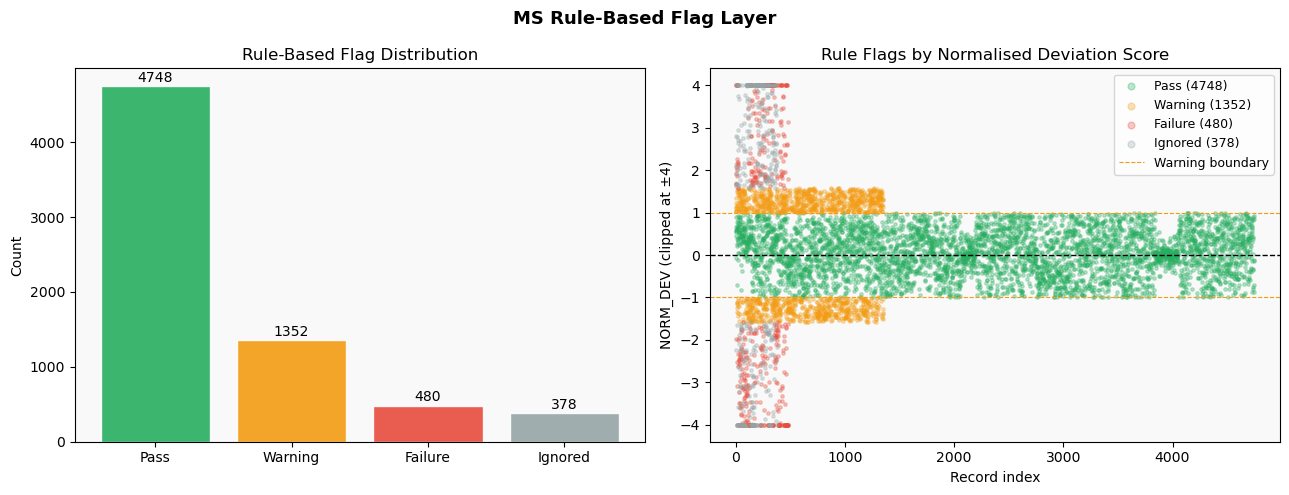

/var/folders/3q/0mjntz6s55qg6qc4g9vvjfyc0000gn/T/ipykernel_49538/596700825.py:222: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(analyte_flags.index, rotation=45, ha="right", fontsize=8)


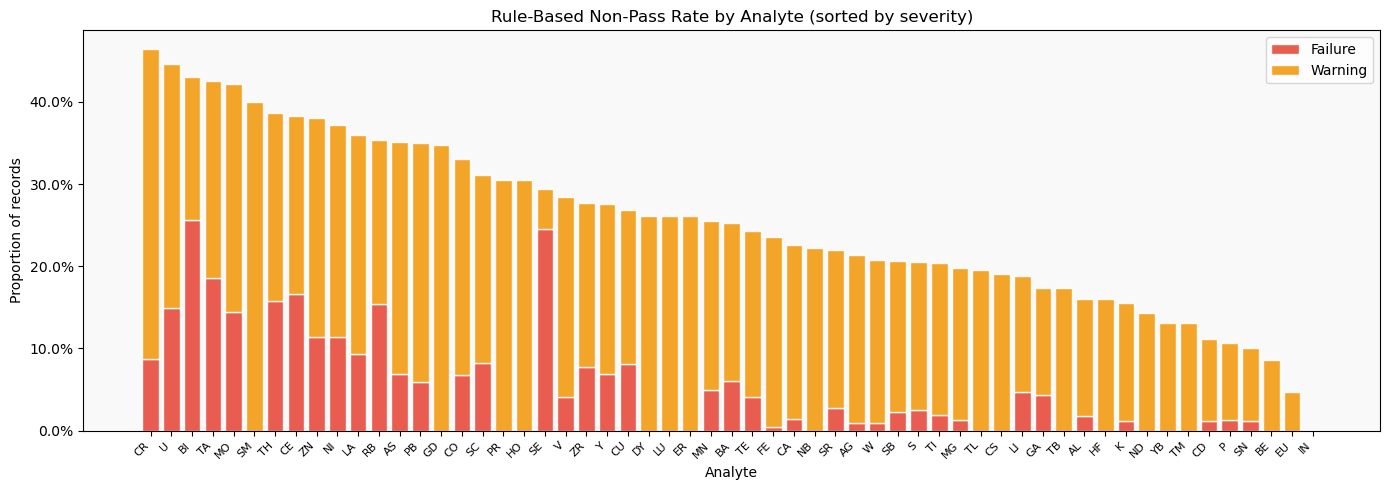

Top 10 analytes by non-pass rate:
ANALYTE_CODE
CR    46.4
U     44.6
BI    43.0
TA    42.6
MO    42.2
SM    40.0
TH    38.6
CE    38.3
ZN    38.1
NI    37.1
Rule-based flag output preview:
   ANALYTE_CODE  SCHEME_CODE  NUMERIC_FINAL_VALUE STANDARD_STATUS RULE_FLAG RULE_FLAG_COLOUR                                          RULE_FLAG_REASON
0            AG  GE_ICP40Q12             1.234450            Pass      Pass            green                       Result within warning limits — Pass
1            AG  GE_ICP40Q12             1.543689            Pass      Pass            green                       Result within warning limits — Pass
2            AG  GE_ICP40Q12             1.650000    UpperWarning   Warning           yellow  Result above upper warning limit (1.6213) — UpperWarning
3            AG  GE_ICP40Q12             1.275510            Pass      Pass            green                       Result within warning limits — Pass
4            AG  GE_ICP40Q12             1.661376    Upp

In [6]:
# """# ---------------------------------------------------------------------------
# Rule-based flag layer
# ---------------------------------------------------------------------------

df = df_features.copy()

def _apply_limit(value, limit, inclusive_flag, direction="upper"):
    
    #Compare value against a limit, respecting the inclusivity flag.
    #direction='upper': returns True if value exceeds the limit (breach)
    #direction='lower': returns True if value is below the limit (breach)
    inclusive = inclusive_flag.astype(str).str.strip().str.upper() == "Y"
    if direction == "upper":
        return np.where(inclusive, value > limit, value >= limit)
    else:
        return np.where(inclusive, value < limit, value <= limit)


def apply_rule_based_flags(df: pd.DataFrame) -> pd.DataFrame:
    
    #Classify each MS record as Failure, Warning, or Pass based on
    #CCLAS failure and warning bounds, respecting limit inclusivity.

    #Returns the DataFrame with three new columns:
    #   RULE_FLAG        — Pass / Warning / Failure / Ignored
    #   RULE_FLAG_COLOUR — green / yellow / red / grey
    #   RULE_FLAG_REASON — plain-language explanation of why the record was flagged

    df = df.copy()

    # Coerce limit columns to numeric
    for col in ["INTERNAL_MIN_VALUE", "INTERNAL_MAX_VALUE",
                "INTERNAL_MIN_WARNING_VALUE", "INTERNAL_MAX_WARNING_VALUE"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    val = df["NUMERIC_FINAL_VALUE"]
    min_fail = df["INTERNAL_MIN_VALUE"]
    max_fail = df["INTERNAL_MAX_VALUE"]
    min_warn = df["INTERNAL_MIN_WARNING_VALUE"]
    max_warn = df["INTERNAL_MAX_WARNING_VALUE"]

    # Fill missing inclusivity flags with Y (inclusive by default)
    min_incl = df.get("INTERNAL_MIN_INCLUSIVE", pd.Series("Y", index=df.index)).fillna("Y")
    max_incl = df.get("INTERNAL_MAX_INCLUSIVE", pd.Series("Y", index=df.index)).fillna("Y")
    min_warn_incl = df.get("INTERNAL_MIN_WARNING_INCLUSIVE", pd.Series("Y", index=df.index)).fillna("Y")
    max_warn_incl = df.get("INTERNAL_MAX_WARNING_INCLUSIVE", pd.Series("Y", index=df.index)).fillna("Y")

    # Failure conditions
    below_min_fail = _apply_limit(val, min_fail, min_incl, direction="lower")
    above_max_fail = _apply_limit(val, max_fail, max_incl, direction="upper")
    is_failure = below_min_fail | above_max_fail

    # Warning conditions (within failure bounds but outside warning bounds)
    below_min_warn = _apply_limit(val, min_warn, min_warn_incl, direction="lower")
    above_max_warn = _apply_limit(val, max_warn, max_warn_incl, direction="upper")
    is_warning = (~is_failure) & (below_min_warn | above_max_warn)

    # Ignored records
    is_ignored = df["IS_IGNORED"]

    # Assign flags
    df["RULE_FLAG"] = np.select(
        [is_ignored, is_failure, is_warning],
        ["Ignored", "Failure", "Warning"],
        default="Pass"
    )

    df["RULE_FLAG_COLOUR"] = np.select(
        [is_ignored, is_failure, is_warning],
        ["grey", "red", "yellow"],
        default="green"
    )

    # Plain-language flag reason
    df["RULE_FLAG_REASON"] = np.select(
        [
            is_ignored,
            below_min_fail & ~is_ignored,
            above_max_fail & ~is_ignored,
            below_min_warn & ~is_failure & ~is_ignored,
            above_max_warn & ~is_failure & ~is_ignored,
        ],
        [
            "Result manually ignored in CCLAS — excluded from modelling baselines",
            "Result below lower failure limit (" + min_fail.round(4).astype(str) + ") — LowerFailure",
            "Result above upper failure limit (" + max_fail.round(4).astype(str) + ") — UpperFailure",
            "Result below lower warning limit (" + min_warn.round(4).astype(str) + ") — LowerWarning",
            "Result above upper warning limit (" + max_warn.round(4).astype(str) + ") — UpperWarning",
        ],
        default="Result within warning limits — Pass"
    )

    return df


df = apply_rule_based_flags(df)

# Summary
flag_counts = df["RULE_FLAG"].value_counts()
print("Rule-based flag distribution:")
for flag, count in flag_counts.items():
    pct = count / len(df) * 100
    print(f"  {flag:<10} {count:>5}  ({pct:.1f}%)")


# Validate Against CCLAS STANDARD_STATUS

#Cross-reference the rule-based flags against the existing CCLAS `STANDARD_STATUS` values to confirm the layer is replicating known classifications correctly. The model should agree with CCLAS on clear failures and passes, and surface the same warning cases.


# Agreement between RULE_FLAG and STANDARD_STATUS
comparison = pd.crosstab(
    df["STANDARD_STATUS"],
    df["RULE_FLAG"],
    margins=True
)
print("STANDARD_STATUS vs RULE_FLAG cross-tabulation:")
print(comparison.to_string())
print()

# Compute agreement rate (excluding Ignored)
non_ignored = df[~df["IS_IGNORED"]].copy()
non_ignored["CCLAS_SIMPLIFIED"] = np.select(
    [
        non_ignored["STANDARD_STATUS"].isin(["UpperFailure", "LowerFailure"]),
        non_ignored["STANDARD_STATUS"].isin(["UpperWarning", "LowerWarning"]),
    ],
    ["Failure", "Warning"],
    default="Pass"
)

agreement = (non_ignored["RULE_FLAG"] == non_ignored["CCLAS_SIMPLIFIED"]).mean()
print(f"Agreement rate with CCLAS (excluding ignored): {agreement*100:.1f}%")
print()

# Cases where model disagrees with CCLAS
disagree = non_ignored[non_ignored["RULE_FLAG"] != non_ignored["CCLAS_SIMPLIFIED"]]
print(f"Disagreement cases: {len(disagree)}")
if len(disagree) > 0:
    print(disagree[["ANALYTE_CODE", "NUMERIC_FINAL_VALUE", "INTERNAL_MIN_VALUE",
                     "INTERNAL_MAX_VALUE", "STANDARD_STATUS", "RULE_FLAG",
                     "RULE_FLAG_REASON"]].head(10).to_string())


# Visualise Rule-Based Flags

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("MS Rule-Based Flag Layer", fontsize=13, fontweight="bold")

colour_map = {
    "Pass":    "#27ae60",
    "Warning": "#f39c12",
    "Failure": "#e74c3c",
    "Ignored": "#95a5a6",
}

# Plot 1 — flag distribution bar chart
ax = axes[0]
flag_order = ["Pass", "Warning", "Failure", "Ignored"]
counts = [df["RULE_FLAG"].eq(f).sum() for f in flag_order]
colours = [colour_map[f] for f in flag_order]
bars = ax.bar(flag_order, counts, color=colours, alpha=0.9, edgecolor="white")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Count")
ax.set_title("Rule-Based Flag Distribution")
ax.set_facecolor("#f9f9f9")

# Plot 2 — NORM_DEV scatter coloured by RULE_FLAG
ax = axes[1]
for flag, colour in colour_map.items():
    subset = df[df["RULE_FLAG"] == flag]
    ax.scatter(
        range(len(subset)),
        subset["NORM_DEV"].clip(-4, 4),
        c=colour, alpha=0.3, s=6, label=f"{flag} ({len(subset)})"
    )
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(1, color="#f39c12", linestyle="--", linewidth=0.8, label="Warning boundary")
ax.axhline(-1, color="#f39c12", linestyle="--", linewidth=0.8)
ax.set_xlabel("Record index")
ax.set_ylabel("NORM_DEV (clipped at ±4)")
ax.set_title("Rule Flags by Normalised Deviation Score")
ax.legend(fontsize=9, markerscale=2)
ax.set_facecolor("#f9f9f9")

fig.tight_layout()
plt.show()

# Rule Flag Summary by Analyte

#Shows which analytes have the highest failure and warning rates under the rule-based layer.


analyte_flags = (
    df[df["RULE_FLAG"] != "Ignored"]
    .groupby("ANALYTE_CODE")["RULE_FLAG"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
for col in ["Pass", "Warning", "Failure"]:
    if col not in analyte_flags.columns:
        analyte_flags[col] = 0

analyte_flags["non_pass_rate"] = 1 - analyte_flags.get("Pass", 0)
analyte_flags = analyte_flags.sort_values("non_pass_rate", ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(analyte_flags))
for col, colour in [("Failure", "#e74c3c"), ("Warning", "#f39c12")]:
    if col in analyte_flags.columns:
        vals = analyte_flags[col].values
        ax.bar(analyte_flags.index, vals, bottom=bottom,
               color=colour, alpha=0.9, label=col, edgecolor="white")
        bottom += vals

ax.set_xlabel("Analyte")
ax.set_ylabel("Proportion of records")
ax.set_title("Rule-Based Non-Pass Rate by Analyte (sorted by severity)")
ax.legend(fontsize=10)
ax.set_xticklabels(analyte_flags.index, rotation=45, ha="right", fontsize=8)
ax.set_facecolor("#f9f9f9")
import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
fig.tight_layout()
plt.show()

print("Top 10 analytes by non-pass rate:")
print(analyte_flags["non_pass_rate"].head(10).mul(100).round(1).to_string())

# Feature Output Preview

#The rule-based flag columns are now appended to the feature-engineered DataFrame and will be passed to the machine learning detection layer as additional input signals.

print("Rule-based flag output preview:")
preview_cols = [
    "ANALYTE_CODE", "SCHEME_CODE", "NUMERIC_FINAL_VALUE",
    "STANDARD_STATUS", "RULE_FLAG", "RULE_FLAG_COLOUR", "RULE_FLAG_REASON"
]
print(df[preview_cols].head(15).to_string())
print()
print(f"Columns in dataset after rule-based layer: {len(df.columns)}")
print(f"New columns added: ['RULE_FLAG', 'RULE_FLAG_COLOUR', 'RULE_FLAG_REASON']")
